<a href="https://colab.research.google.com/github/jadghazi/codealpha_tasks/blob/Intern_Tasks/employment_analysis_Data_Science_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/jadghazi/codealpha_tasks/refs/heads/Intern_Tasks/Unemployment%20in%20India.csv"
df = pd.read_csv(url)

# Preview data
print(df.head())


           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  


In [3]:
# Strip extra whitespace from column names
df.columns = df.columns.str.strip()

# Rename columns for consistency
df.columns = ['Region', 'Date', 'Frequency', 'Unemployment_Rate',
              'Employed', 'Labour_Participation_Rate', 'Area']

# Remove leading/trailing spaces in Date column and convert to datetime
df['Date'] = df['Date'].str.strip()
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Check data types and missing values
print(df.info())
print("\nMissing values:\n", df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Region                     740 non-null    object        
 1   Date                       740 non-null    datetime64[ns]
 2   Frequency                  740 non-null    object        
 3   Unemployment_Rate          740 non-null    float64       
 4   Employed                   740 non-null    float64       
 5   Labour_Participation_Rate  740 non-null    float64       
 6   Area                       740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 42.1+ KB
None

Missing values:
 Region                       28
Date                         28
Frequency                    28
Unemployment_Rate            28
Employed                     28
Labour_Participation_Rate    28
Area                         28
dtype: int

In [4]:
# Drop rows with all null values
df.dropna(inplace=True)

# Confirm shape after dropping
print(f"Shape after cleaning: {df.shape}")


Shape after cleaning: (740, 7)


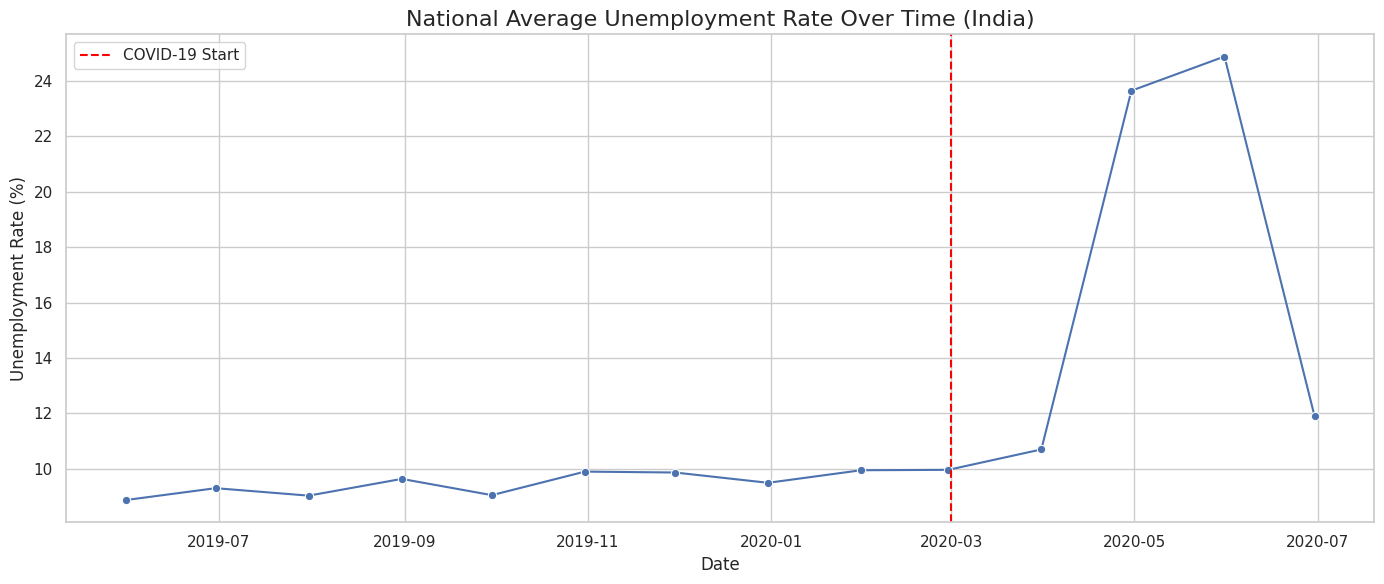

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Group by Date to get national average unemployment
national_trend = df.groupby('Date')['Unemployment_Rate'].mean().reset_index()

# Plot national unemployment trend
plt.figure(figsize=(14,6))
sns.lineplot(data=national_trend, x='Date', y='Unemployment_Rate', marker='o')
plt.title('National Average Unemployment Rate Over Time (India)', fontsize=16)
plt.ylabel('Unemployment Rate (%)')
plt.xlabel('Date')
plt.axvline(pd.to_datetime('2020-03-01'), color='red', linestyle='--', label='COVID-19 Start')
plt.legend()
plt.tight_layout()
plt.show()


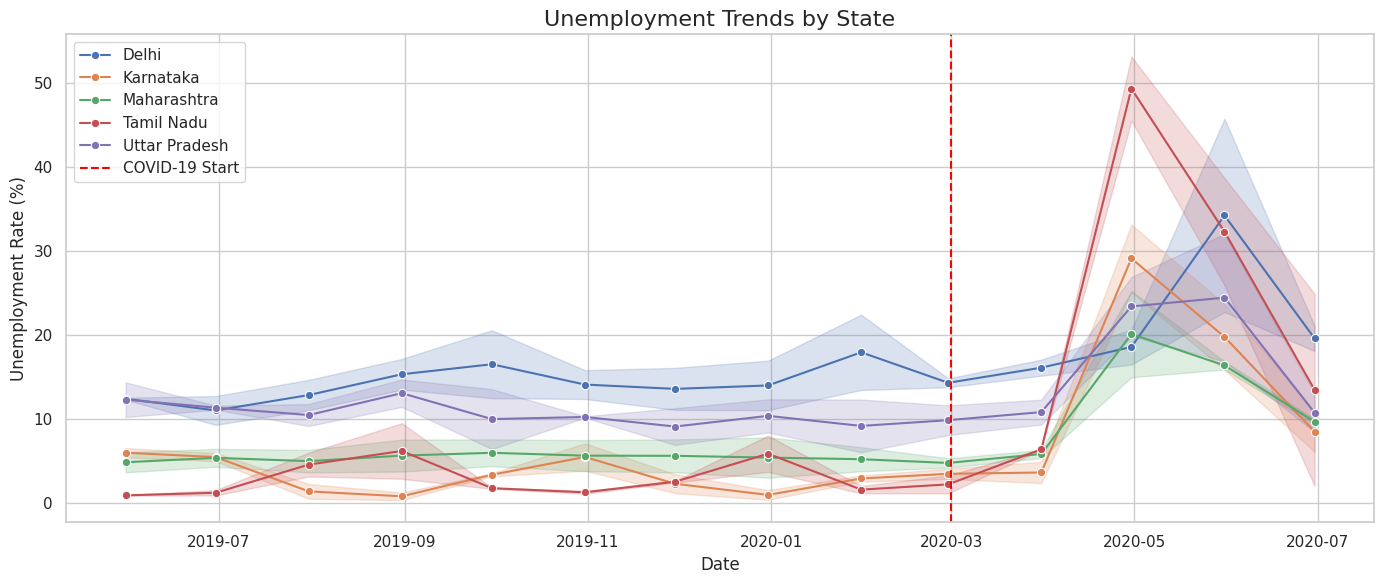

In [6]:
# Select a few representative states
selected_states = ['Delhi', 'Maharashtra', 'Tamil Nadu', 'Uttar Pradesh', 'Karnataka']

# Filter dataset for those states
filtered_df = df[df['Region'].isin(selected_states)]

# Plot unemployment trends
plt.figure(figsize=(14,6))
sns.lineplot(data=filtered_df, x='Date', y='Unemployment_Rate', hue='Region', marker='o')
plt.title('Unemployment Trends by State', fontsize=16)
plt.ylabel('Unemployment Rate (%)')
plt.xlabel('Date')
plt.axvline(pd.to_datetime('2020-03-01'), color='red', linestyle='--', label='COVID-19 Start')
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipython-input-7-879816434.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly_avg, x='Year', y='Unemployment_Rate', palette='viridis')


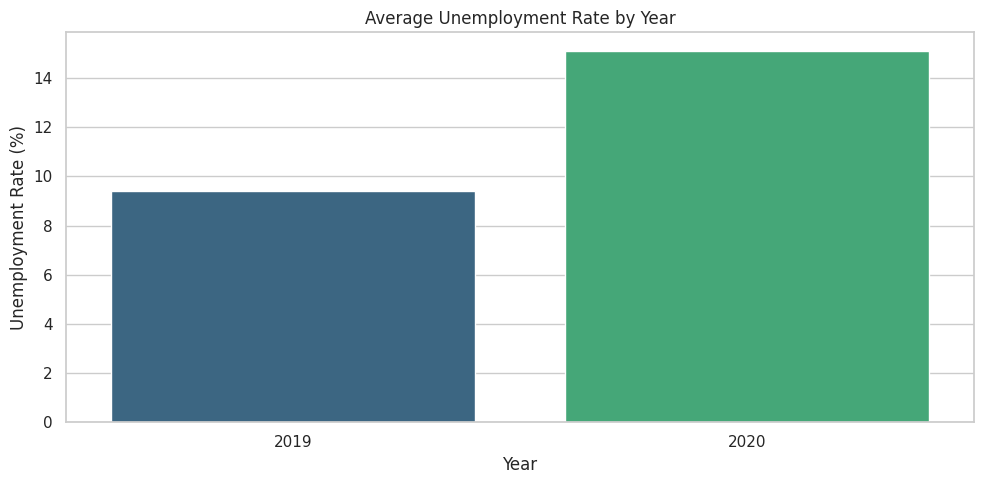

In [7]:
# Create Year and Month columns
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()

# Group by Year to see average unemployment per year
yearly_avg = df.groupby('Year')['Unemployment_Rate'].mean().reset_index()

# Plot yearly averages
plt.figure(figsize=(10,5))
sns.barplot(data=yearly_avg, x='Year', y='Unemployment_Rate', palette='viridis')
plt.title('Average Unemployment Rate by Year')
plt.ylabel('Unemployment Rate (%)')
plt.xlabel('Year')
plt.tight_layout()
plt.show()


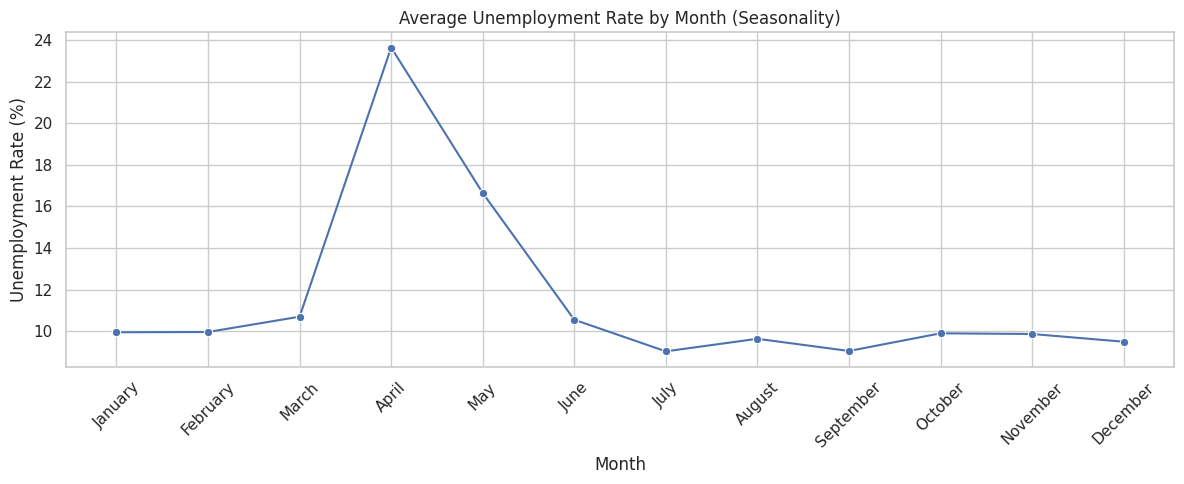

In [8]:
# Order months correctly
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Group by Month across all years
monthly_avg = df.groupby('Month')['Unemployment_Rate'].mean().reindex(month_order).reset_index()

# Plot month-wise trend
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_avg, x='Month', y='Unemployment_Rate', marker='o')
plt.title('Average Unemployment Rate by Month (Seasonality)')
plt.ylabel('Unemployment Rate (%)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**INSIGHTS**

1. COVID-19's Impact
Unemployment spiked significantly in March–May 2020, peaking nationally.

States like Delhi and Maharashtra saw sharp increases, likely due to their urban economies and lockdown sensitivity.

2. Regional Disparities
Unemployment rates varied significantly by state — indicating regional economic resilience or vulnerability.

Urban regions generally had more volatile unemployment during the pandemic.

3. Seasonal Patterns
Some months (e.g., May-June) show slightly elevated unemployment, possibly due to:

Agricultural off-seasons

School or college completion leading to job search periods

This suggests cyclical employment trends, especially in rural areas.

4. Year-over-Year Trends
2020 shows the highest average unemployment across all years in the dataset.

Slight recovery is visible in late 2021 onward, though not all regions return to pre-COVID levels.

** POLICY RECOMMENDATIONS**

 1. Strengthen Employment Safety Nets During Disruptions
Pandemic spikes highlight the need for temporary unemployment benefits, especially in urban labor sectors.

 2. Support Seasonal Workers
Rural areas may benefit from targeted employment programs during known low-employment months (e.g., MGNREGA boost in off-seasons).

 3. Regional Skill Development
States with high volatility may need reskilling/upskilling initiatives, especially in tourism, manufacturing, and gig sectors.

 4. Focus on Urban Job Stability
Urban employment needs crisis-proofing mechanisms like social insurance, flexible contracts, or remote work infrastructure.

